<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# we import  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
df= pd.read_csv("bank-loan.csv")
print(df.head())

   age  ed  employ  address  income  debtinc   creddebt   othdebt  default  \
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0   
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0   
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0   
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0   
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0   

   Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12 Unnamed: 13 Unnamed: 14  \
0         NaN          NaN          NaN          NaN         NaN         NaN   
1         NaN          NaN          NaN  Credit card        2200         NaN   
2         NaN          NaN          NaN    Car  loan         450         NaN   
3         NaN          NaN          NaN  Total debts        2650         NaN   
4         NaN          NaN          NaN       income         NaN         NaN   

  Unnamed: 15 Unnamed: 16 Unnamed: 17 Unnamed: 18 

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          850 non-null    int64  
 1   ed           850 non-null    int64  
 2   employ       850 non-null    int64  
 3   address      850 non-null    int64  
 4   income       850 non-null    int64  
 5   debtinc      850 non-null    float64
 6   creddebt     850 non-null    float64
 7   othdebt      850 non-null    float64
 8   default      700 non-null    float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  0 non-null      float64
 12  Unnamed: 12  7 non-null      object 
 13  Unnamed: 13  7 non-null      object 
 14  Unnamed: 14  1 non-null      object 
 15  Unnamed: 15  7 non-null      object 
 16  Unnamed: 16  1 non-null      object 
 17  Unnamed: 17  7 non-null      object 
 18  Unnamed: 18  1 non-null      object 
 19  Unnamed:

In [ ]:
# checking for misingvalues
print(df.isnull().sum())


age              0
ed               0
employ           0
address          0
income           0
debtinc          0
creddebt         0
othdebt          0
default        150
Unnamed: 9     850
Unnamed: 10    850
Unnamed: 11    850
Unnamed: 12    843
Unnamed: 13    843
Unnamed: 14    849
Unnamed: 15    843
Unnamed: 16    849
Unnamed: 17    843
Unnamed: 18    849
Unnamed: 19    850
dtype: int64


In [ ]:
# handling missing values
# Drop columns that are mostly (or entirely) empty (the 'Unnamed' columns)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

# Now, handle missing values in the 'default' column
# Since 'default' is the target variable, dropping rows with missing 'default' is often appropriate.
df.dropna(subset=['default'], inplace=True)

print(df.isnull().sum())

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64


/tmp/ipykernel_24578/76659948.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['default'], inplace=True)


In [ ]:
print(df.describe(include='all'))

        age   ed  employ  address  income  debtinc  creddebt  othdebt  \
count   0.0  0.0     0.0      0.0     0.0      0.0       0.0      0.0   
unique  NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
top     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
freq    NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
mean    NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
std     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
min     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
25%     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
50%     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
75%     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   
max     NaN  NaN     NaN      NaN     NaN      NaN       NaN      NaN   

        default  Unnamed: 9  Unnamed: 10  Unnamed: 11 Unnamed: 12 Unnamed: 13  \
count       0.0         0.0          0.0  

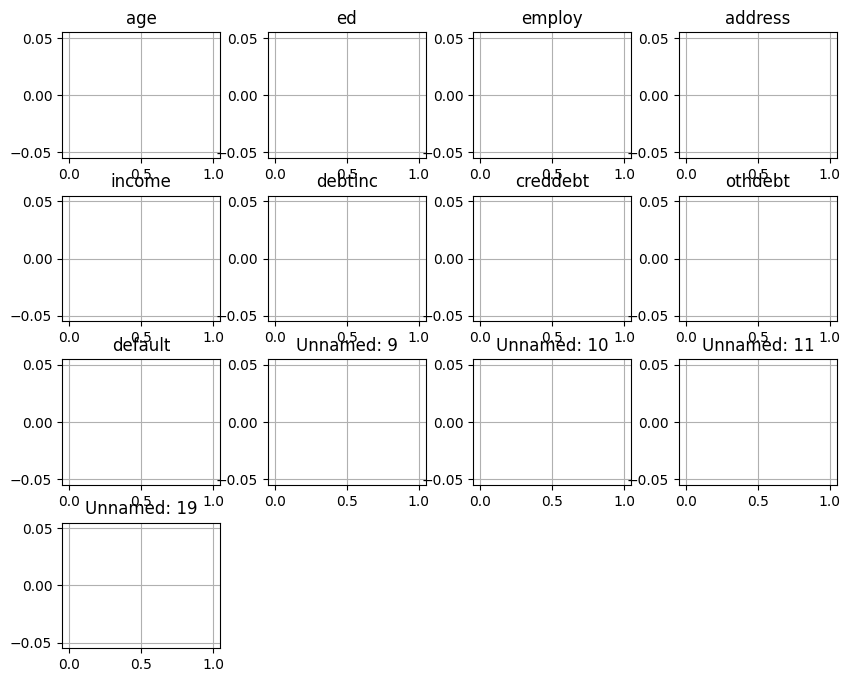

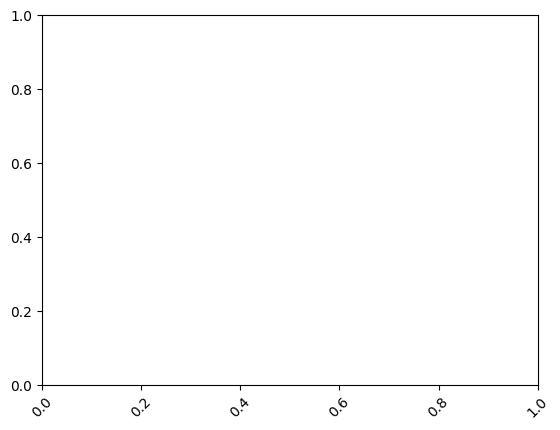

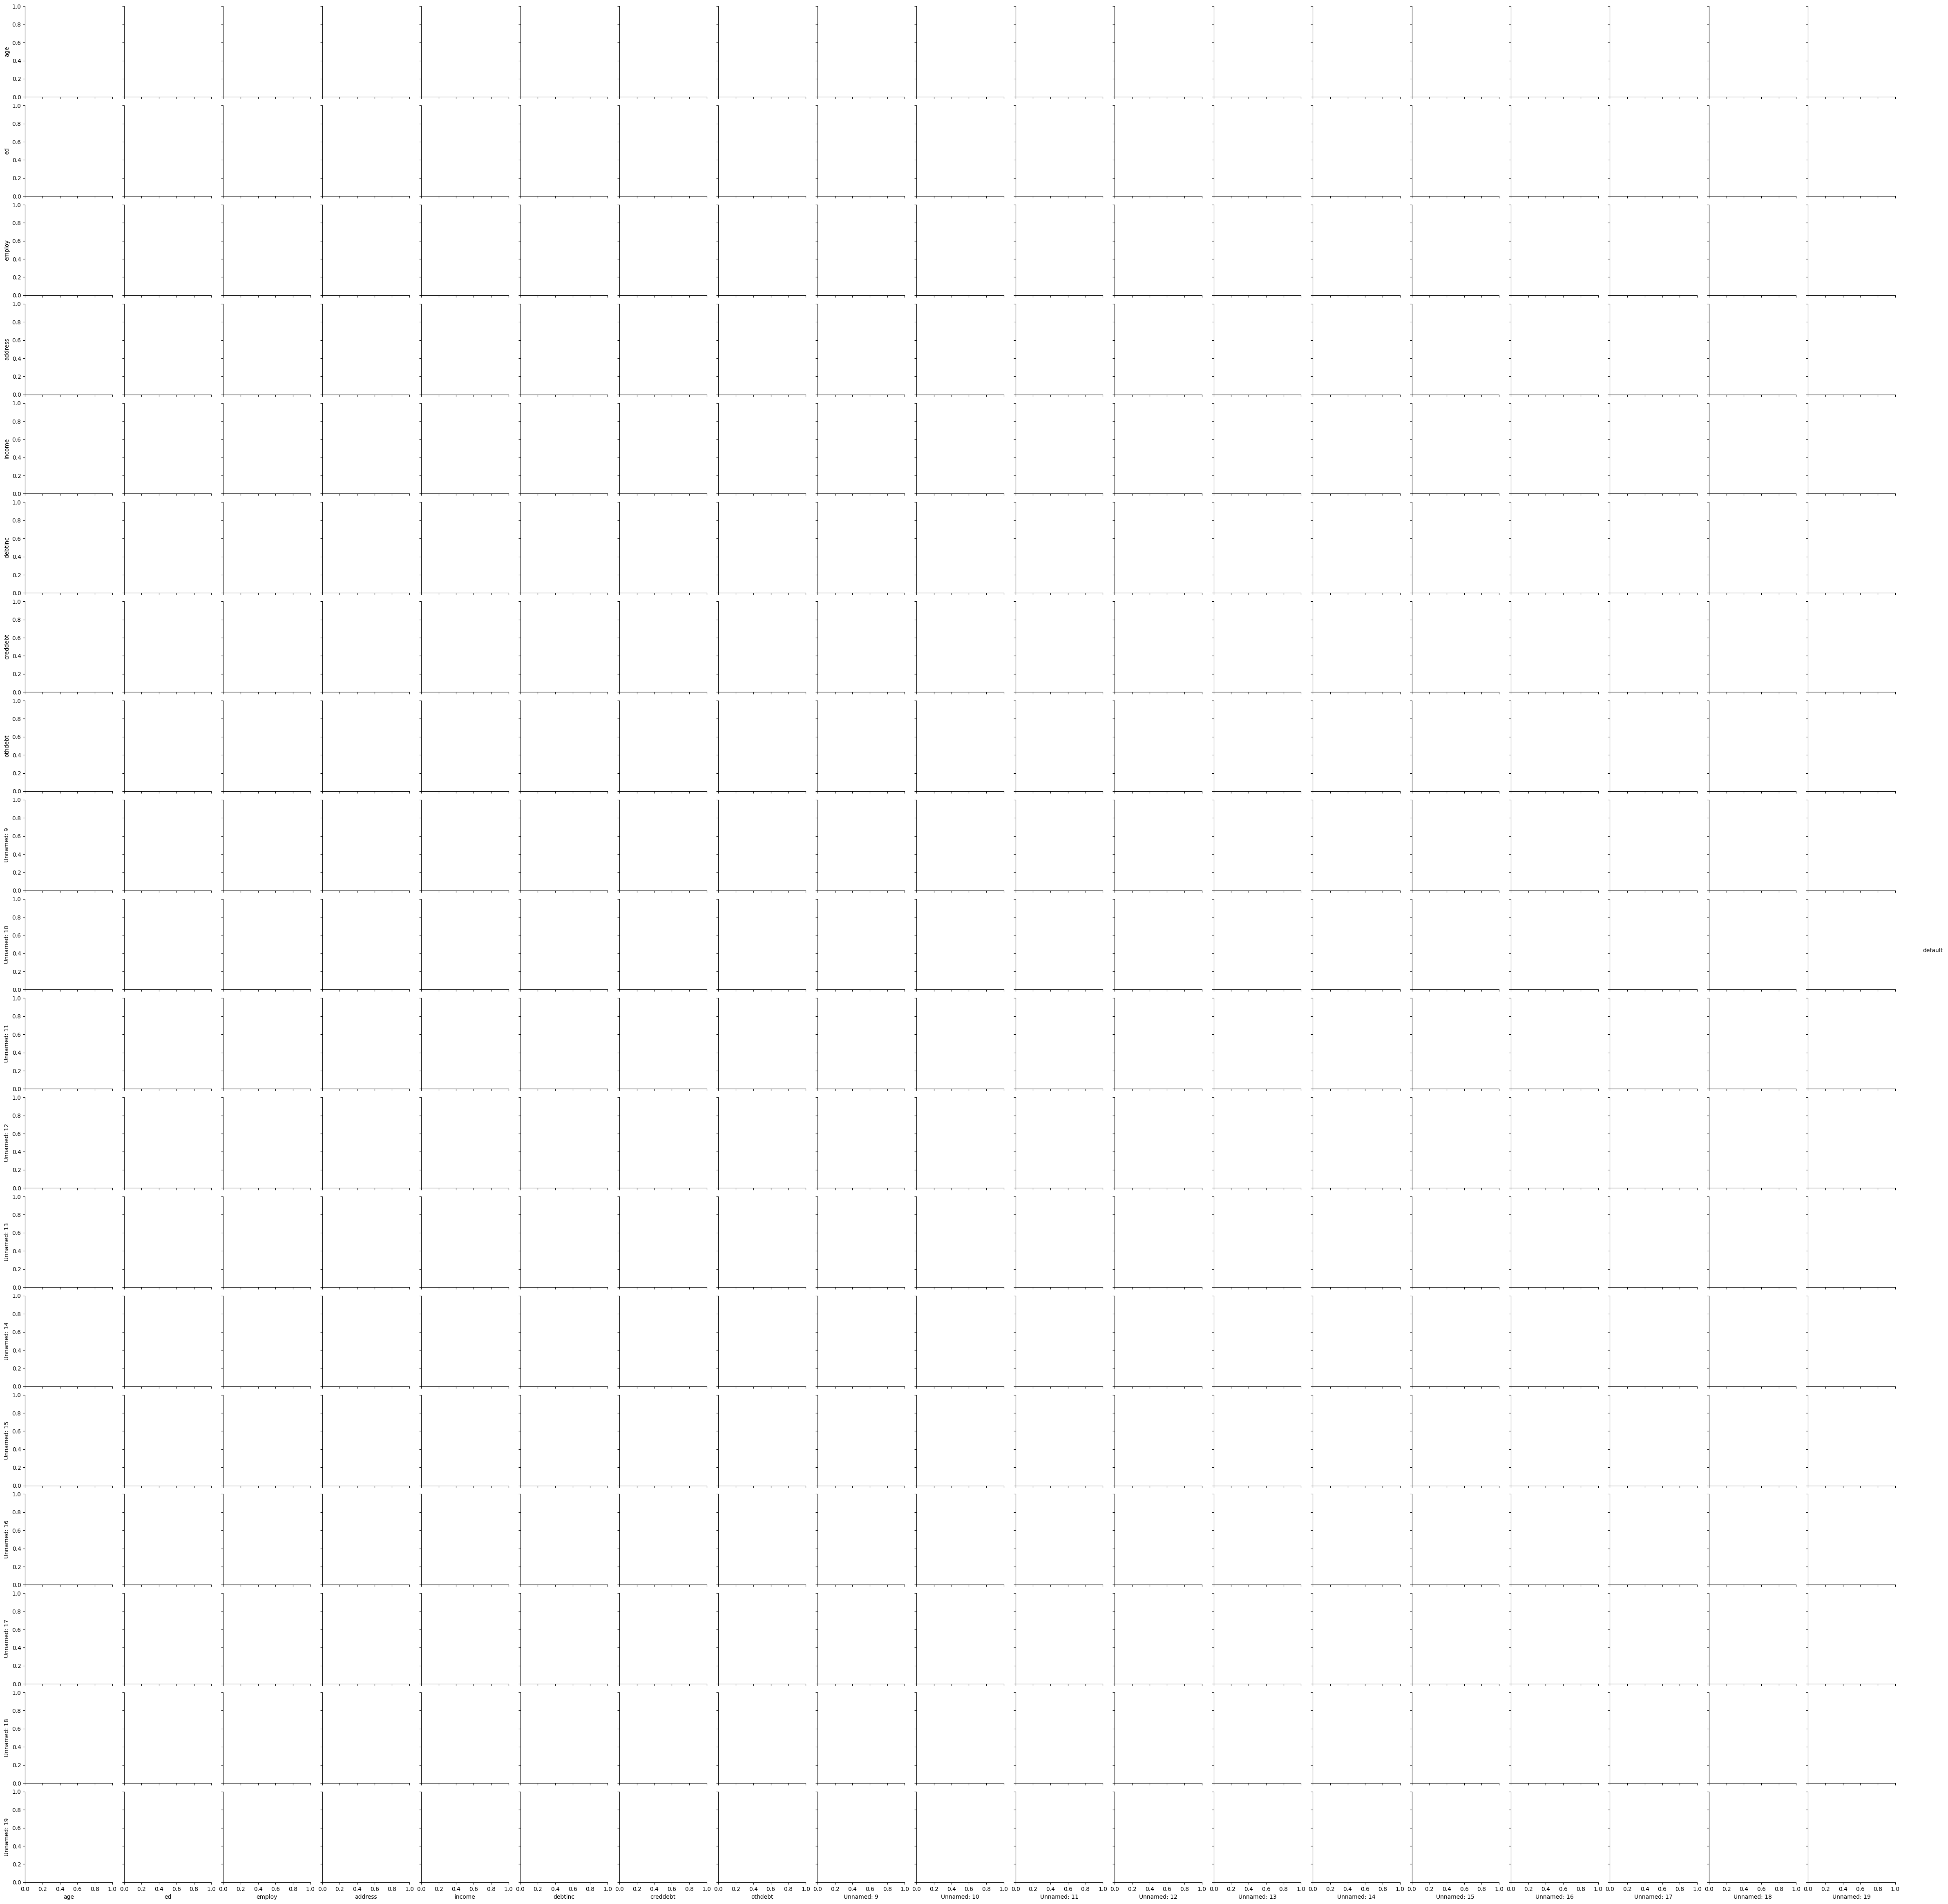

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


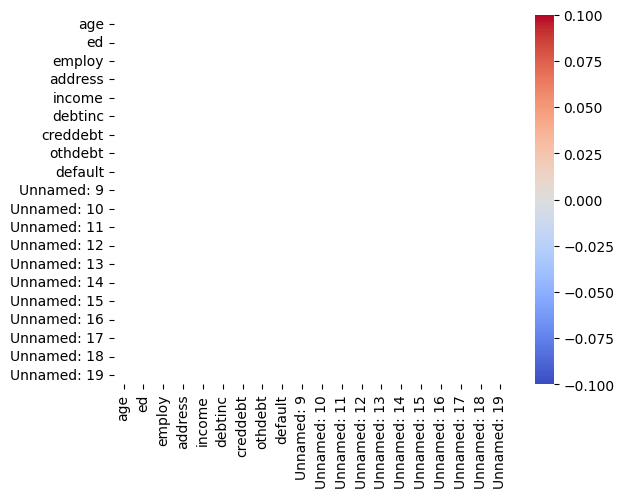

In [ ]:
# data  visualization
# Distribution of features
df.hist(figsize=(10,8))
plt.show()

# Boxplots (detect outliers)
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

# Pairwise relationships
sns.pairplot(df, hue='default')
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# normalization
num_cols = ['age', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by StandardScaler.

In [ ]:
# feature engeneering
df['total_debt'] = df['creddebt'] + df['othdebt']
df['high_debt_burden'] = df['debtinc'] * df['income']
df['debt_income_ratio'] = df['total_debt'] / (df['income'] + 1)
print(df.head())


In [ ]:
# Model development
X = df.drop('default', axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Train model
rf.fit(X_train, y_train)


In [ ]:
# Predictions
y_pred = rf.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'y_test' is not defined